In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [13]:
from pathlib import Path

data_dir = Path(r"C:\Users\Richa\OneDrive\文档\idx exchange")

In [14]:
# sample month imput testing
sample_file = data_dir / "CRMLSSold202510.csv"
df_sample = pd.read_csv(sample_file)
df_sample.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,NorthSanLuisObispo,NorthSanLuisObispo,NaN,NaN,NaN,NaN,NaN,NaN,479293596,newlin@pacificaCRE.com,...,NaN,1807.0,NaN,NaN,NaN,NaN,93446,NaN,1807.0,NaN
1,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,NaN,12000.0,446914808,nleimers@hotmail.com,...,NaN,14253.0,NaN,False,NaN,NaN,92325,0.0,14253.0,NaN
2,SanDiego,SanDiego,Wood,True,NaN,NaN,False,1695.0,445176588,mannybehar@yahoo.com,...,NaN,NaN,NaN,NaN,0.0,NaN,92126,0.0,NaN,NaN
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,950000.0,1145282039,chase@cromwellhomegroup.com,...,NaN,NaN,NaN,False,2.0,NaN,91901,NaN,NaN,NaN
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,970000.0,1145278097,rory@corneliusestates.net,...,NaN,NaN,NaN,False,2.0,NaN,92115,NaN,NaN,NaN


In [ ]:
#file inputs
files = [
    "CRMLSSold202510.csv",
    "CRMLSSold202511.csv",
    "CRMLSSold202512.csv",
    "CRMLSSold202601.csv",
    "CRMLSSold202602.csv",
    "CRMLSSold202603.csv",
]

dfs = []
for f in files:
    path = data_dir / f
    temp = pd.read_csv(path)
    temp["SourceFile"] = f
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print(df.shape)
df.head(5)

C:\Users\Richa\AppData\Local\Temp\ipykernel_35708\1927989732.py:13: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(path)


(120053, 79)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,SourceFile
0,NorthSanLuisObispo,NorthSanLuisObispo,NaN,NaN,NaN,NaN,NaN,NaN,479293596,newlin@pacificaCRE.com,...,1807.0,NaN,NaN,NaN,NaN,93446,NaN,1807.0,NaN,CRMLSSold202510.csv
1,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,NaN,12000.0,446914808,nleimers@hotmail.com,...,14253.0,NaN,False,NaN,NaN,92325,0.0,14253.0,NaN,CRMLSSold202510.csv
2,SanDiego,SanDiego,Wood,True,NaN,NaN,False,1695.0,445176588,mannybehar@yahoo.com,...,NaN,NaN,NaN,0.0,NaN,92126,0.0,NaN,NaN,CRMLSSold202510.csv
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,950000.0,1145282039,chase@cromwellhomegroup.com,...,NaN,NaN,False,2.0,NaN,91901,NaN,NaN,NaN,CRMLSSold202510.csv
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,970000.0,1145278097,rory@corneliusestates.net,...,NaN,NaN,False,2.0,NaN,92115,NaN,NaN,NaN,CRMLSSold202510.csv


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120053 entries, 0 to 120052
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 118089 non-null  str    
 1   ListAgentAOR                  120011 non-null  str    
 2   Flooring                      70089 non-null   str    
 3   ViewYN                        108010 non-null  object 
 4   WaterfrontYN                  67 non-null      object 
 5   BasementYN                    1940 non-null    object 
 6   PoolPrivateYN                 107051 non-null  object 
 7   OriginalListPrice             119706 non-null  float64
 8   ListingKey                    120053 non-null  int64  
 9   ListAgentEmail                119737 non-null  str    
 10  CloseDate                     120053 non-null  str    
 11  ClosePrice                    120051 non-null  float64
 12  ListAgentFirstName            119551 non-null  str    


In [ ]:
#residential filter
df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()
print(df.shape)
df.head(5)

(59440, 79)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,SourceFile
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,950000.0,1145282039,chase@cromwellhomegroup.com,...,NaN,NaN,False,2.0,NaN,91901,NaN,NaN,NaN,CRMLSSold202510.csv
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,970000.0,1145278097,rory@corneliusestates.net,...,NaN,NaN,False,2.0,NaN,92115,NaN,NaN,NaN,CRMLSSold202510.csv
5,SanDiego,SanDiego,NaN,False,NaN,NaN,False,575000.0,1145277224,garylawrence@kw.com,...,NaN,NaN,False,2.0,NaN,91945,NaN,NaN,NaN,CRMLSSold202510.csv
7,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Tile,True,NaN,NaN,False,1243810.0,1145272633,taylor@acme-re.com,...,2066.0,NaN,True,NaN,NaN,90065,141.25,2066.0,NaN,CRMLSSold202510.csv
8,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Tile,True,NaN,NaN,False,1227060.0,1145272243,taylor@acme-re.com,...,1804.0,NaN,True,NaN,NaN,90065,141.25,1804.0,NaN,CRMLSSold202510.csv


In [ ]:
#missing values
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

CoveredSpaces                   59440
BusinessType                    59440
ElementarySchoolDistrict        59440
MiddleOrJuniorSchoolDistrict    59440
TaxAnnualAmount                 59440
AboveGradeFinishedArea          59440
FireplacesTotal                 59440
TaxYear                         59440
WaterfrontYN                    59405
BelowGradeFinishedArea          59020
BasementYN                      58024
BuilderName                     56680
LotSizeDimensions               55661
BuildingAreaTotal               55485
CoBuyerAgentFirstName           53953
ElementarySchool                52077
MiddleOrJuniorSchool            52020
HighSchool                      49650
CoListAgentFirstName            45460
CoListAgentLastName             45413
AssociationFeeFrequency         44239
CoListOfficeName                43336
SubdivisionName                 38410
MainLevelBedrooms               22786
Flooring                        21547
AssociationFee                  16809
HighSchoolDi

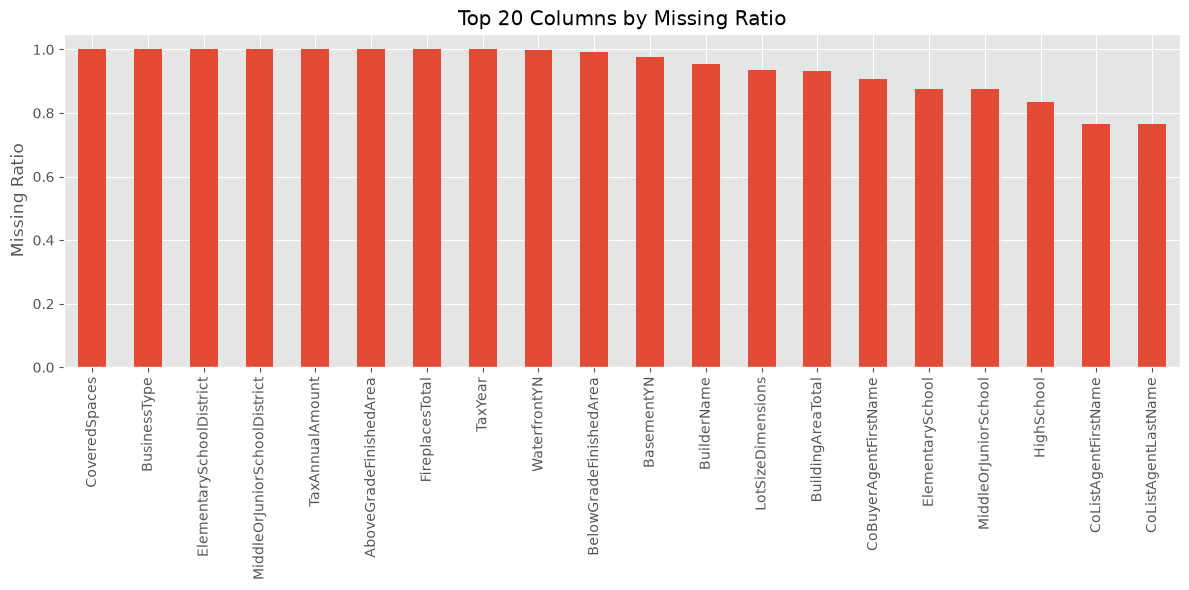

In [20]:
#missing visualization
missing_ratio = (
    df.isnull()
      .mean()
      .sort_values(ascending=False)
)

missing_ratio = missing_ratio[missing_ratio > 0]

plt.figure(figsize=(12, 6))
missing_ratio.head(20).plot(kind="bar")
plt.ylabel("Missing Ratio")
plt.title("Top 20 Columns by Missing Ratio")
plt.tight_layout()
plt.show()

In [21]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2


In [ ]:
#main columns for analysis
core_cols = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet"
]

df[core_cols].describe()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
count,5.944000e+04,59413.000000,59440.00000,59439.000000,5.843200e+04
mean,1.311860e+06,2048.367325,3.49603,2.633288,6.470325e+05
std,7.344166e+06,1039.787678,0.97245,1.127432,2.403396e+07
min,1.750000e+00,0.000000,0.00000,0.000000,0.000000e+00
25%,6.150000e+05,1384.000000,3.00000,2.000000,5.663000e+03
50%,8.750000e+05,1816.000000,3.00000,2.000000,7.261000e+03
75%,1.385000e+06,2441.000000,4.00000,3.000000,1.045400e+04
max,9.895000e+08,31068.000000,22.00000,23.000000,1.938943e+09


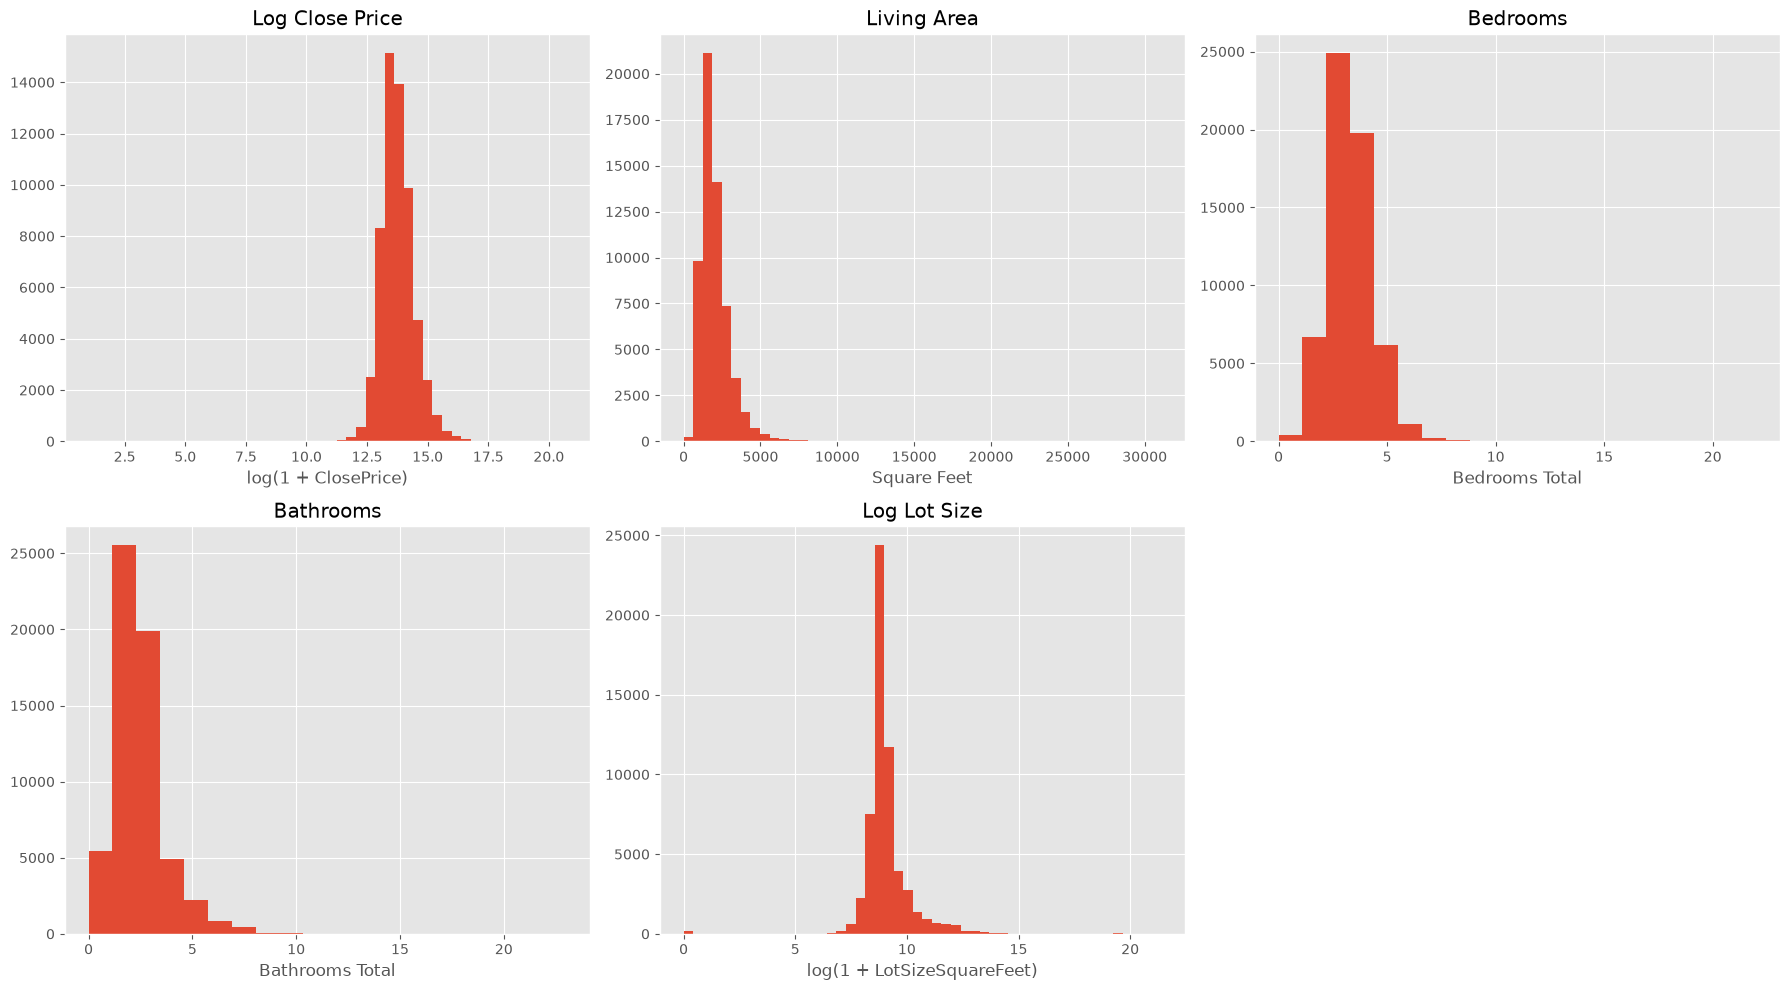

In [ ]:
#Distribution of Key Variables
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(np.log1p(df["ClosePrice"].dropna()), bins=50)
axes[0, 0].set_title("Log Close Price")
axes[0, 0].set_xlabel("log(1 + ClosePrice)")

axes[0, 1].hist(df["LivingArea"].dropna(), bins=50)
axes[0, 1].set_title("Living Area")
axes[0, 1].set_xlabel("Square Feet")

axes[0, 2].hist(df["BedroomsTotal"].dropna(), bins=20)
axes[0, 2].set_title("Bedrooms")
axes[0, 2].set_xlabel("Bedrooms Total")

axes[1, 0].hist(df["BathroomsTotalInteger"].dropna(), bins=20)
axes[1, 0].set_title("Bathrooms")
axes[1, 0].set_xlabel("Bathrooms Total")

axes[1, 1].hist(np.log1p(df["LotSizeSquareFeet"].dropna()), bins=50)
axes[1, 1].set_title("Log Lot Size")
axes[1, 1].set_xlabel("log(1 + LotSizeSquareFeet)")

fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

C:\Users\Richa\AppData\Local\Temp\ipykernel_35708\364288246.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 0].boxplot(df["ClosePrice"].dropna(), vert=True)
C:\Users\Richa\AppData\Local\Temp\ipykernel_35708\364288246.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(df["LivingArea"].dropna(), vert=True)
C:\Users\Richa\AppData\Local\Temp\ipykernel_35708\364288246.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 0].boxplot(df["LotSizeSquareFeet"].dropna(), vert=True)
C:\Users\Richa\AppData\Local\Temp\ipykernel_35708\364288246.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and w

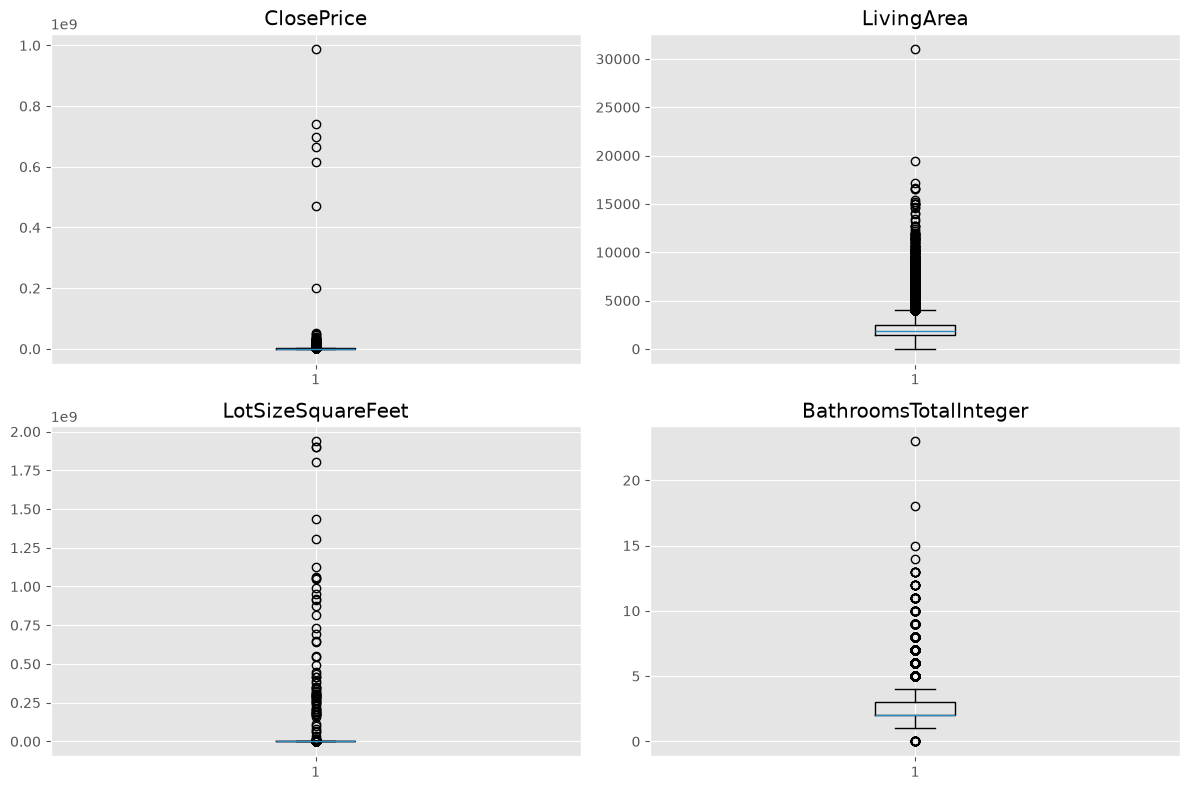

In [ ]:
#Detect Outliers Using Boxplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].boxplot(df["ClosePrice"].dropna(), vert=True)
axes[0, 0].set_title("ClosePrice")

axes[0, 1].boxplot(df["LivingArea"].dropna(), vert=True)
axes[0, 1].set_title("LivingArea")

axes[1, 0].boxplot(df["LotSizeSquareFeet"].dropna(), vert=True)
axes[1, 0].set_title("LotSizeSquareFeet")

axes[1, 1].boxplot(df["BathroomsTotalInteger"].dropna(), vert=True)
axes[1, 1].set_title("BathroomsTotalInteger")

plt.tight_layout()
plt.show()

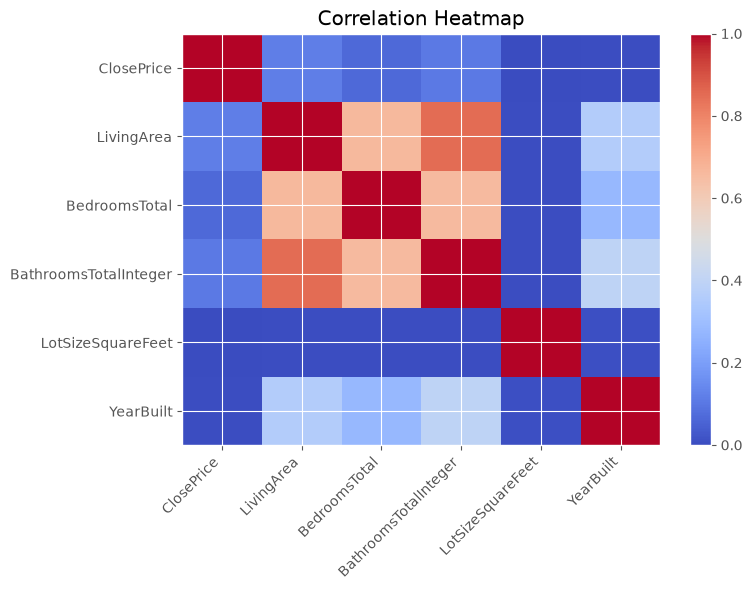

In [ ]:
#Correlation Analysis and Heatmap
corr_cols = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt"
]

corr = df[corr_cols].corr()
corr
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()